In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

print("All libraries imported successfully.")
print(f"PyTorch version : {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device          : {device}")

All libraries imported successfully.
PyTorch version : 2.11.0+cpu
Device          : cpu


In [2]:
# Load All Artifacts 
# Load config
with open('../models/config.json', 'r') as f:
    config = json.load(f)

VOCAB_SIZE          = config['VOCAB_SIZE']
MAX_SEQUENCE_LENGTH = config['MAX_SEQUENCE_LENGTH']
BATCH_SIZE          = config['BATCH_SIZE']
NUM_CLASSES         = config['NUM_CLASSES']
PAD_IDX             = config['PAD_IDX']

# Load vocabulary
with open('../models/word2idx.pkl', 'rb') as f:
    word2idx = pickle.load(f)

with open('../models/idx2word.pkl', 'rb') as f:
    idx2word = pickle.load(f)

# Load tensors
X_train = torch.load('../models/X_train.pt')
y_train = torch.load('../models/y_train.pt')
X_valid = torch.load('../models/X_valid.pt')
y_valid = torch.load('../models/y_valid.pt')

# Load class weights
class_weights = torch.load('../models/class_weights.pt').to(device)

print(f"VOCAB_SIZE          : {VOCAB_SIZE}")
print(f"MAX_SEQUENCE_LENGTH : {MAX_SEQUENCE_LENGTH}")
print(f"BATCH_SIZE          : {BATCH_SIZE}")
print(f"NUM_CLASSES         : {NUM_CLASSES}")
print(f"PAD_IDX             : {PAD_IDX}")
print()
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_valid : {X_valid.shape}")
print(f"y_valid : {y_valid.shape}")
print()
print(f"Class weights : {class_weights}")

VOCAB_SIZE          : 6306
MAX_SEQUENCE_LENGTH : 32
BATCH_SIZE          : 64
NUM_CLASSES         : 3
PAD_IDX             : 0

X_train : torch.Size([9535, 32])
y_train : torch.Size([9535])
X_valid : torch.Size([2388, 32])
y_valid : torch.Size([2388])

Class weights : tensor([2.2041, 1.6528, 0.5151])


In [3]:
# Dataset & DataLoader 
class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SentimentDataset(X_train, y_train)
valid_dataset = SentimentDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Valid batches : {len(valid_loader)}")

Train batches : 149
Valid batches : 38


In [5]:
#Training & Evaluation Functions
label_names = ['Bearish', 'Bullish', 'Neutral']

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs    = model(X_batch)
            loss       = criterion(outputs, y_batch)
            total_loss += loss.item()
            preds      = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1, all_preds, all_labels


def plot_training_curves(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='steelblue')
    axes[0].plot(epochs, history['valid_loss'], label='Valid Loss', color='tomato')
    axes[0].set_title(f'{model_name} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train Acc', color='steelblue')
    axes[1].plot(epochs, history['valid_acc'], label='Valid Acc', color='tomato')
    axes[1].set_title(f'{model_name} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    axes[2].plot(epochs, history['train_f1'], label='Train F1', color='steelblue')
    axes[2].plot(epochs, history['valid_f1'], label='Valid F1', color='tomato')
    axes[2].set_title(f'{model_name} — Macro F1')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()

    plt.suptitle(f'{model_name} — Training Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../assets/{model_name}_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Plot saved to assets/{model_name}_training_curves.png")


def plot_confusion_matrix(all_labels, all_preds, model_name):
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names)
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'../assets/{model_name}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Plot saved to assets/{model_name}_confusion_matrix.png")


def print_classification_report(all_labels, all_preds, model_name):
    print(f"\n{model_name} — Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=label_names))


print("✓ Training and evaluation functions defined.")

✓ Training and evaluation functions defined.


In [6]:
# Model Architectures 

class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers, dropout, pad_idx):
        super(SentimentRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn       = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers,
                                batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded         = self.dropout(self.embedding(x))
        _, hidden        = self.rnn(embedded)
        hidden           = self.dropout(hidden[-1])
        return self.fc(hidden)


class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers, dropout, pad_idx):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                                 batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded        = self.dropout(self.embedding(x))
        _, (hidden, _)  = self.lstm(embedded)
        hidden          = self.dropout(hidden[-1])
        return self.fc(hidden)


class SentimentGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers, dropout, pad_idx):
        super(SentimentGRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru       = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers,
                                batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded  = self.dropout(self.embedding(x))
        _, hidden = self.gru(embedded)
        hidden    = self.dropout(hidden[-1])
        return self.fc(hidden)


print("✓ RNN, LSTM, GRU model architectures defined.")

✓ RNN, LSTM, GRU model architectures defined.


In [7]:
# Hyperparameters 
EMBED_DIM   = 128
HIDDEN_DIM  = 256
NUM_LAYERS  = 2
DROPOUT     = 0.3
EPOCHS      = 20
LR          = 1e-3
PATIENCE    = 5        # early stopping patience

print("Hyperparameters:")
print(f"  EMBED_DIM  : {EMBED_DIM}")
print(f"  HIDDEN_DIM : {HIDDEN_DIM}")
print(f"  NUM_LAYERS : {NUM_LAYERS}")
print(f"  DROPOUT    : {DROPOUT}")
print(f"  EPOCHS     : {EPOCHS}")
print(f"  LR         : {LR}")
print(f"  PATIENCE   : {PATIENCE}")

# Full Training Loop with Early Stopping 
def train_model(model, model_name, train_loader, valid_loader,
                epochs, lr, patience, class_weights):

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'valid_loss': [],
               'train_acc' : [], 'valid_acc' : [],
               'train_f1'  : [], 'valid_f1'  : []}

    best_valid_f1   = 0.0
    patience_counter = 0
    best_model_path  = f'../models/{model_name}_best.pt'

    print(f"\n{'='*60}")
    print(f"  Training {model_name}")
    print(f"{'='*60}")

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = train_epoch(model, train_loader, optimizer, criterion)
        valid_loss, valid_acc, valid_f1, _, _ = evaluate(model, valid_loader, criterion)

        history['train_loss'].append(train_loss)
        history['valid_loss'].append(valid_loss)
        history['train_acc'].append(train_acc)
        history['valid_acc'].append(valid_acc)
        history['train_f1'].append(train_f1)
        history['valid_f1'].append(valid_f1)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
              f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f} | Valid F1: {valid_f1:.4f}", end="")

        # Early stopping — monitor validation macro F1
        if valid_f1 > best_valid_f1:
            best_valid_f1 = valid_f1
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print("  ← best model saved")
        else:
            patience_counter += 1
            print(f"  (patience {patience_counter}/{patience})")
            if patience_counter >= patience:
                print(f"\n⚠ Early stopping triggered at epoch {epoch}.")
                break

    print(f"\n✓ Best Valid Macro F1 : {best_valid_f1:.4f}")
    print(f"✓ Model saved to      : {best_model_path}")
    return history, best_valid_f1

print("\n✓ Hyperparameters and training loop defined.")

Hyperparameters:
  EMBED_DIM  : 128
  HIDDEN_DIM : 256
  NUM_LAYERS : 2
  DROPOUT    : 0.3
  EPOCHS     : 20
  LR         : 0.001
  PATIENCE   : 5

✓ Hyperparameters and training loop defined.


In [8]:
# Train Simple RNN
rnn_model = SentimentRNN(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_classes = NUM_CLASSES,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
    pad_idx     = PAD_IDX
).to(device)

print(f"RNN Model Architecture:\n{rnn_model}")
print(f"\nTotal parameters : {sum(p.numel() for p in rnn_model.parameters()):,}")

rnn_history, rnn_best_f1 = train_model(
    model        = rnn_model,
    model_name   = 'SimpleRNN',
    train_loader = train_loader,
    valid_loader = valid_loader,
    epochs       = EPOCHS,
    lr           = LR,
    patience     = PATIENCE,
    class_weights= class_weights
)

RNN Model Architecture:
SentimentRNN(
  (embedding): Embedding(6306, 128, padding_idx=0)
  (rnn): RNN(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

Total parameters : 1,038,339

  Training SimpleRNN
Epoch 01/20 | Train Loss: 1.1021 | Train Acc: 0.3211 | Train F1: 0.2957 | Valid Loss: 1.0935 | Valid Acc: 0.3869 | Valid F1: 0.2578  ← best model saved
Epoch 02/20 | Train Loss: 1.1072 | Train Acc: 0.3669 | Train F1: 0.3132 | Valid Loss: 1.1255 | Valid Acc: 0.1449 | Valid F1: 0.0844  (patience 1/5)
Epoch 03/20 | Train Loss: 1.1015 | Train Acc: 0.3709 | Train F1: 0.3111 | Valid Loss: 1.0787 | Valid Acc: 0.6558 | Valid F1: 0.2640  ← best model saved
Epoch 04/20 | Train Loss: 1.1045 | Train Acc: 0.3948 | Train F1: 0.3138 | Valid Loss: 1.2036 | Valid Acc: 0.2399 | Valid F1: 0.2410  (patience 1/5)
Epoch 05/20 | Train Loss: 1.1346 | Train Acc: 0.3261 | Train F1: 0.2953 | Valid Loss: 1

In [9]:
# Train LSTM 
lstm_model = SentimentLSTM(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_classes = NUM_CLASSES,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
    pad_idx     = PAD_IDX
).to(device)

print(f"LSTM Model Architecture:\n{lstm_model}")
print(f"\nTotal parameters : {sum(p.numel() for p in lstm_model.parameters()):,}")

lstm_history, lstm_best_f1 = train_model(
    model         = lstm_model,
    model_name    = 'LSTM',
    train_loader  = train_loader,
    valid_loader  = valid_loader,
    epochs        = EPOCHS,
    lr            = LR,
    patience      = PATIENCE,
    class_weights = class_weights
)

LSTM Model Architecture:
SentimentLSTM(
  (embedding): Embedding(6306, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

Total parameters : 1,729,539

  Training LSTM
Epoch 01/20 | Train Loss: 1.0998 | Train Acc: 0.3490 | Train F1: 0.3007 | Valid Loss: 1.0935 | Valid Acc: 0.6558 | Valid F1: 0.2640  ← best model saved
Epoch 02/20 | Train Loss: 1.0991 | Train Acc: 0.4176 | Train F1: 0.3247 | Valid Loss: 1.0896 | Valid Acc: 0.6558 | Valid F1: 0.2640  (patience 1/5)
Epoch 03/20 | Train Loss: 1.0987 | Train Acc: 0.4356 | Train F1: 0.3095 | Valid Loss: 1.1065 | Valid Acc: 0.2056 | Valid F1: 0.1183  (patience 2/5)
Epoch 04/20 | Train Loss: 1.1004 | Train Acc: 0.3364 | Train F1: 0.2935 | Valid Loss: 1.1009 | Valid Acc: 0.1453 | Valid F1: 0.0846  (patience 3/5)
Epoch 05/20 | Train Loss: 1.0989 | Train Acc: 0.4363 | Train F1: 0.3152 | Valid Loss: 1.1002

In [10]:
# Retrain LSTM with lower LR 
LR_LSTM = 3e-4   # lower than default 1e-3

lstm_model = SentimentLSTM(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_classes = NUM_CLASSES,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
    pad_idx     = PAD_IDX
).to(device)

print(f"Retraining LSTM with LR = {LR_LSTM}")
print(f"Total parameters : {sum(p.numel() for p in lstm_model.parameters()):,}")

lstm_history, lstm_best_f1 = train_model(
    model         = lstm_model,
    model_name    = 'LSTM',
    train_loader  = train_loader,
    valid_loader  = valid_loader,
    epochs        = EPOCHS,
    lr            = LR_LSTM,
    patience      = PATIENCE,
    class_weights = class_weights
)

Retraining LSTM with LR = 0.0003
Total parameters : 1,729,539

  Training LSTM
Epoch 01/20 | Train Loss: 1.0992 | Train Acc: 0.4113 | Train F1: 0.3188 | Valid Loss: 1.0854 | Valid Acc: 0.6558 | Valid F1: 0.2640  ← best model saved
Epoch 02/20 | Train Loss: 1.0988 | Train Acc: 0.4955 | Train F1: 0.3254 | Valid Loss: 1.0993 | Valid Acc: 0.1989 | Valid F1: 0.1106  (patience 1/5)
Epoch 03/20 | Train Loss: 1.0989 | Train Acc: 0.3320 | Train F1: 0.2720 | Valid Loss: 1.0861 | Valid Acc: 0.6558 | Valid F1: 0.2640  (patience 2/5)
Epoch 04/20 | Train Loss: 1.0911 | Train Acc: 0.4722 | Train F1: 0.3425 | Valid Loss: 1.0165 | Valid Acc: 0.6089 | Valid F1: 0.3820  ← best model saved
Epoch 05/20 | Train Loss: 1.0473 | Train Acc: 0.5619 | Train F1: 0.4077 | Valid Loss: 0.9511 | Valid Acc: 0.6424 | Valid F1: 0.4470  ← best model saved
Epoch 06/20 | Train Loss: 0.9813 | Train Acc: 0.6079 | Train F1: 0.4735 | Valid Loss: 0.9999 | Valid Acc: 0.5808 | Valid F1: 0.4649  ← best model saved
Epoch 07/20 | Tra

In [11]:
# Train GRU 
LR_GRU = 3e-4   # same lower LR that worked for LSTM

gru_model = SentimentGRU(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_classes = NUM_CLASSES,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
    pad_idx     = PAD_IDX
).to(device)

print(f"GRU Model Architecture:\n{gru_model}")
print(f"\nTotal parameters : {sum(p.numel() for p in gru_model.parameters()):,}")

gru_history, gru_best_f1 = train_model(
    model         = gru_model,
    model_name    = 'GRU',
    train_loader  = train_loader,
    valid_loader  = valid_loader,
    epochs        = EPOCHS,
    lr            = LR_GRU,
    patience      = PATIENCE,
    class_weights = class_weights
)

GRU Model Architecture:
SentimentGRU(
  (embedding): Embedding(6306, 128, padding_idx=0)
  (gru): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

Total parameters : 1,499,139

  Training GRU
Epoch 01/20 | Train Loss: 1.0995 | Train Acc: 0.3943 | Train F1: 0.3175 | Valid Loss: 1.0964 | Valid Acc: 0.1453 | Valid F1: 0.0846  ← best model saved
Epoch 02/20 | Train Loss: 1.0990 | Train Acc: 0.3781 | Train F1: 0.3113 | Valid Loss: 1.1078 | Valid Acc: 0.1989 | Valid F1: 0.1106  ← best model saved
Epoch 03/20 | Train Loss: 1.1006 | Train Acc: 0.3827 | Train F1: 0.3136 | Valid Loss: 1.1093 | Valid Acc: 0.1449 | Valid F1: 0.0844  (patience 1/5)
Epoch 04/20 | Train Loss: 1.0983 | Train Acc: 0.3633 | Train F1: 0.3161 | Valid Loss: 1.0549 | Valid Acc: 0.5913 | Valid F1: 0.3522  ← best model saved
Epoch 05/20 | Train Loss: 1.0426 | Train Acc: 0.5285 | Train F1: 0.4051 | Valid Loss: 0.8

In [12]:
# Extend LSTM Training 
EXTRA_EPOCHS = 10

# Load best saved LSTM weights and continue training
lstm_model.load_state_dict(torch.load('../models/LSTM_best.pt'))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LR_LSTM)

print(f"Resuming LSTM training for {EXTRA_EPOCHS} more epochs...")
print(f"Starting from Best Valid Macro F1 : {lstm_best_f1:.4f}")
print(f"{'='*60}")

best_valid_f1    = lstm_best_f1
patience_counter = 0

for epoch in range(1, EXTRA_EPOCHS + 1):
    train_loss, train_acc, train_f1 = train_epoch(lstm_model, train_loader, optimizer, criterion)
    valid_loss, valid_acc, valid_f1, _, _ = evaluate(lstm_model, valid_loader, criterion)

    lstm_history['train_loss'].append(train_loss)
    lstm_history['valid_loss'].append(valid_loss)
    lstm_history['train_acc'].append(train_acc)
    lstm_history['valid_acc'].append(valid_acc)
    lstm_history['train_f1'].append(train_f1)
    lstm_history['valid_f1'].append(valid_f1)

    print(f"Epoch {20+epoch:02d}/{20+EXTRA_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | "
          f"Valid Loss: {valid_loss:.4f} | Valid F1: {valid_f1:.4f}", end="")

    if valid_f1 > best_valid_f1:
        best_valid_f1    = valid_f1
        patience_counter = 0
        torch.save(lstm_model.state_dict(), '../models/LSTM_best.pt')
        print("  ← best model saved")
    else:
        patience_counter += 1
        print(f"  (patience {patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n⚠ Early stopping triggered.")
            break

lstm_best_f1 = best_valid_f1
print(f"\n✓ Final Best LSTM Valid Macro F1 : {lstm_best_f1:.4f}")

Resuming LSTM training for 10 more epochs...
Starting from Best Valid Macro F1 : 0.7115
Epoch 21/30 | Train Loss: 0.4311 | Train F1: 0.8018 | Valid Loss: 0.6872 | Valid F1: 0.7026  (patience 1/5)
Epoch 22/30 | Train Loss: 0.4035 | Train F1: 0.8201 | Valid Loss: 0.6902 | Valid F1: 0.6940  (patience 2/5)
Epoch 23/30 | Train Loss: 0.3764 | Train F1: 0.8304 | Valid Loss: 0.6446 | Valid F1: 0.7186  ← best model saved
Epoch 24/30 | Train Loss: 0.3655 | Train F1: 0.8362 | Valid Loss: 0.7332 | Valid F1: 0.7150  (patience 1/5)
Epoch 25/30 | Train Loss: 0.3531 | Train F1: 0.8388 | Valid Loss: 0.7080 | Valid F1: 0.7113  (patience 2/5)
Epoch 26/30 | Train Loss: 0.3289 | Train F1: 0.8545 | Valid Loss: 0.7313 | Valid F1: 0.7040  (patience 3/5)
Epoch 27/30 | Train Loss: 0.3004 | Train F1: 0.8607 | Valid Loss: 0.7096 | Valid F1: 0.7161  (patience 4/5)
Epoch 28/30 | Train Loss: 0.2991 | Train F1: 0.8592 | Valid Loss: 0.7768 | Valid F1: 0.7284  ← best model saved
Epoch 29/30 | Train Loss: 0.2791 | Train

In [13]:
#Extend GRU Training
gru_model.load_state_dict(torch.load('../models/GRU_best.pt'))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(gru_model.parameters(), lr=LR_GRU)

print(f"Resuming GRU training for {EXTRA_EPOCHS} more epochs...")
print(f"Starting from Best Valid Macro F1 : {gru_best_f1:.4f}")
print(f"{'='*60}")

best_valid_f1    = gru_best_f1
patience_counter = 0

for epoch in range(1, EXTRA_EPOCHS + 1):
    train_loss, train_acc, train_f1 = train_epoch(gru_model, train_loader, optimizer, criterion)
    valid_loss, valid_acc, valid_f1, _, _ = evaluate(gru_model, valid_loader, criterion)

    gru_history['train_loss'].append(train_loss)
    gru_history['valid_loss'].append(valid_loss)
    gru_history['train_acc'].append(train_acc)
    gru_history['valid_acc'].append(valid_acc)
    gru_history['train_f1'].append(train_f1)
    gru_history['valid_f1'].append(valid_f1)

    print(f"Epoch {20+epoch:02d}/{20+EXTRA_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | "
          f"Valid Loss: {valid_loss:.4f} | Valid F1: {valid_f1:.4f}", end="")

    if valid_f1 > best_valid_f1:
        best_valid_f1    = valid_f1
        patience_counter = 0
        torch.save(gru_model.state_dict(), '../models/GRU_best.pt')
        print("  ← best model saved")
    else:
        patience_counter += 1
        print(f"  (patience {patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n⚠ Early stopping triggered.")
            break

gru_best_f1 = best_valid_f1
print(f"\n✓ Final Best GRU Valid Macro F1 : {gru_best_f1:.4f}")

Resuming GRU training for 10 more epochs...
Starting from Best Valid Macro F1 : 0.7079
Epoch 21/30 | Train Loss: 0.3073 | Train F1: 0.8462 | Valid Loss: 0.7530 | Valid F1: 0.7192  ← best model saved
Epoch 22/30 | Train Loss: 0.2830 | Train F1: 0.8576 | Valid Loss: 0.7753 | Valid F1: 0.7200  ← best model saved
Epoch 23/30 | Train Loss: 0.2652 | Train F1: 0.8675 | Valid Loss: 0.7475 | Valid F1: 0.7171  (patience 1/5)
Epoch 24/30 | Train Loss: 0.2551 | Train F1: 0.8694 | Valid Loss: 0.8072 | Valid F1: 0.7210  ← best model saved
Epoch 25/30 | Train Loss: 0.2502 | Train F1: 0.8734 | Valid Loss: 0.8325 | Valid F1: 0.7203  (patience 1/5)
Epoch 26/30 | Train Loss: 0.2395 | Train F1: 0.8790 | Valid Loss: 0.7430 | Valid F1: 0.7100  (patience 2/5)
Epoch 27/30 | Train Loss: 0.2286 | Train F1: 0.8816 | Valid Loss: 0.8178 | Valid F1: 0.7149  (patience 3/5)
Epoch 28/30 | Train Loss: 0.2076 | Train F1: 0.8914 | Valid Loss: 0.8637 | Valid F1: 0.7339  ← best model saved
Epoch 29/30 | Train Loss: 0.2032 

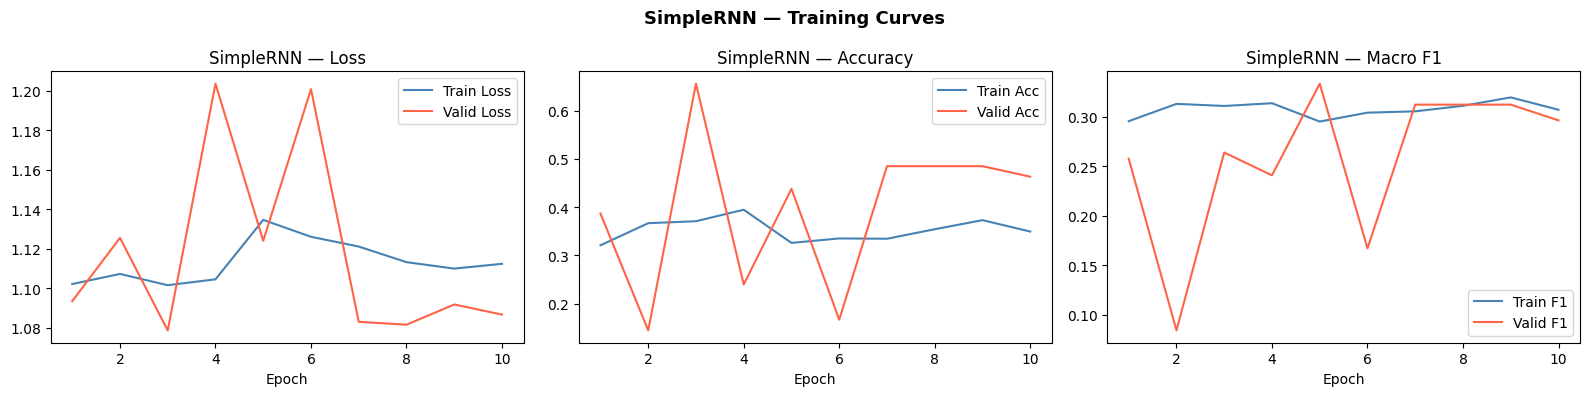

✓ Plot saved to assets/SimpleRNN_training_curves.png


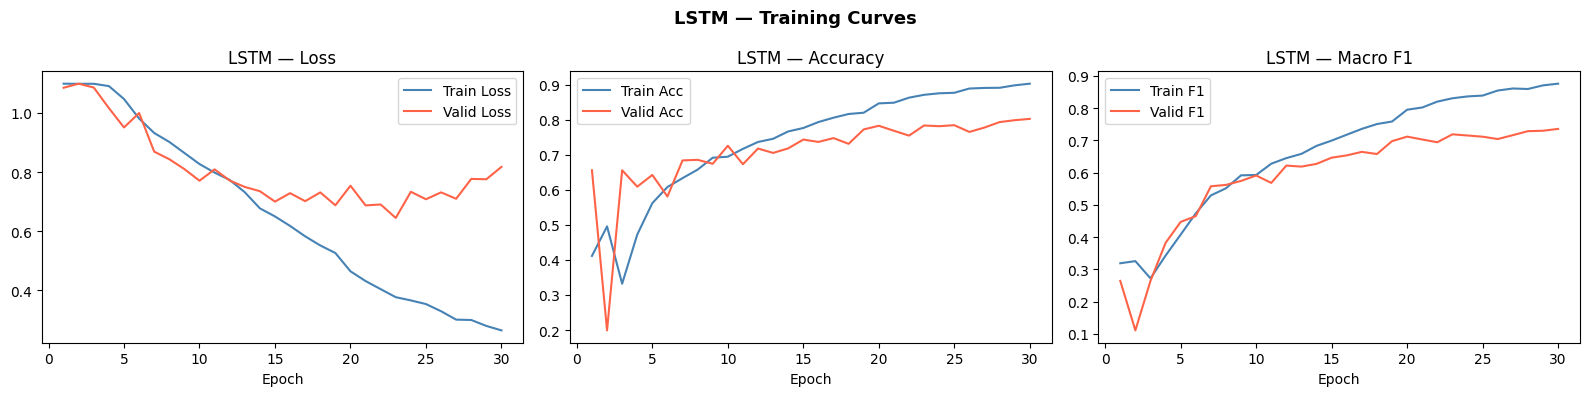

✓ Plot saved to assets/LSTM_training_curves.png


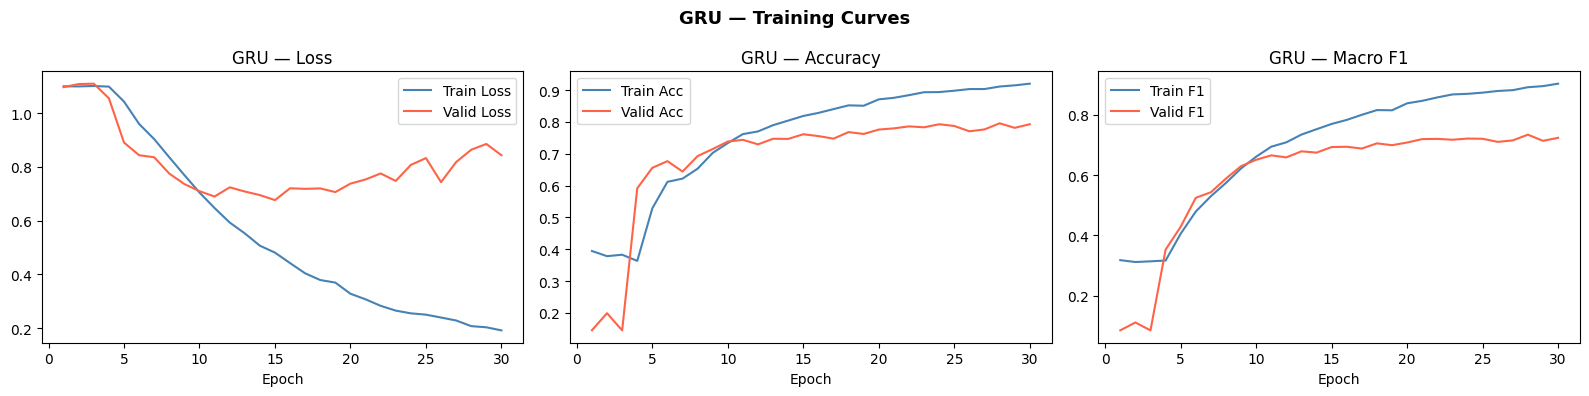

✓ Plot saved to assets/GRU_training_curves.png


In [14]:
# Plot Training Curves 
plot_training_curves(rnn_history,  'SimpleRNN')
plot_training_curves(lstm_history, 'LSTM')
plot_training_curves(gru_history,  'GRU')

In [16]:
# Full Classification Reports 
print("=" * 60)
print("SimpleRNN — Full Classification Report")
print("=" * 60)
print(classification_report(rnn_labels, rnn_preds, target_names=label_names, digits=4))

print("=" * 60)
print("LSTM — Full Classification Report")
print("=" * 60)
print(classification_report(lstm_labels, lstm_preds, target_names=label_names, digits=4))

print("=" * 60)
print("GRU — Full Classification Report")
print("=" * 60)
print(classification_report(gru_labels, gru_preds, target_names=label_names, digits=4))

SimpleRNN — Full Classification Report
              precision    recall  f1-score   support

     Bearish     0.1548    0.3775    0.2196       347
     Bullish     0.2464    0.1453    0.1828       475
     Neutral     0.6704    0.5402    0.5983      1566

    accuracy                         0.4380      2388
   macro avg     0.3572    0.3543    0.3336      2388
weighted avg     0.5111    0.4380    0.4606      2388

LSTM — Full Classification Report
              precision    recall  f1-score   support

     Bearish     0.6687    0.6167    0.6417       347
     Bullish     0.6391    0.7495    0.6899       475
     Neutral     0.8908    0.8595    0.8749      1566

    accuracy                         0.8023      2388
   macro avg     0.7329    0.7419    0.7355      2388
weighted avg     0.8085    0.8023    0.8042      2388

GRU — Full Classification Report
              precision    recall  f1-score   support

     Bearish     0.6070    0.6455    0.6257       347
     Bullish     0.6780

In [17]:
print(classification_report(gru_labels, gru_preds, target_names=label_names, digits=4))

              precision    recall  f1-score   support

     Bearish     0.6070    0.6455    0.6257       347
     Bullish     0.6780    0.7537    0.7139       475
     Neutral     0.8840    0.8416    0.8623      1566

    accuracy                         0.7956      2388
   macro avg     0.7230    0.7470    0.7339      2388
weighted avg     0.8028    0.7956    0.7984      2388



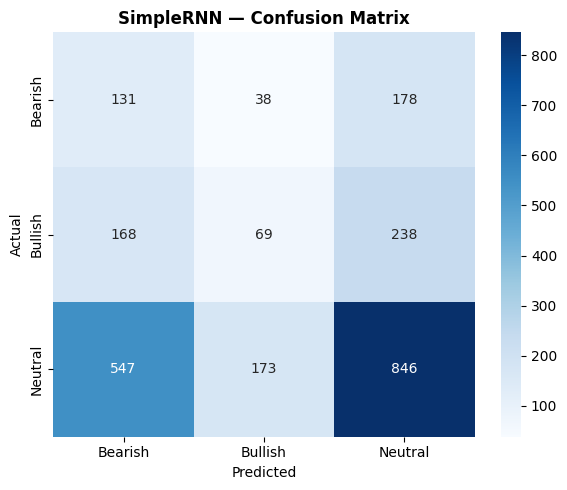

✓ Plot saved to assets/SimpleRNN_confusion_matrix.png


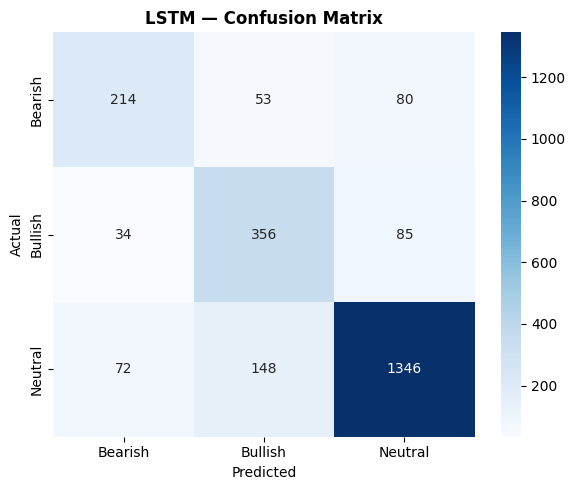

✓ Plot saved to assets/LSTM_confusion_matrix.png


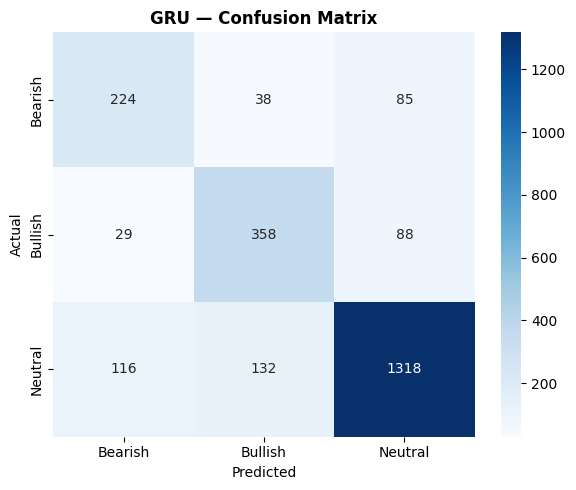

✓ Plot saved to assets/GRU_confusion_matrix.png


In [18]:
# ─── Confusion Matrices ──────────────────────────────────────────────────────
plot_confusion_matrix(rnn_labels,  rnn_preds,  'SimpleRNN')
plot_confusion_matrix(lstm_labels, lstm_preds, 'LSTM')
plot_confusion_matrix(gru_labels,  gru_preds,  'GRU')

In [19]:
# Phase 3 Summary 
print("=" * 60)
print("        PHASE 3 SUMMARY — RNN MODEL COMPARISON")
print("=" * 60)
print(f"""
MODELS TRAINED
  1. Simple RNN  — 2 layers, hidden=256, embed=128, dropout=0.3
  2. LSTM        — 2 layers, hidden=256, embed=128, dropout=0.3
  3. GRU         — 2 layers, hidden=256, embed=128, dropout=0.3

HYPERPARAMETERS
  Embedding Dim  : 128
  Hidden Dim     : 256
  Num Layers     : 2
  Dropout        : 0.3
  Batch Size     : 64
  SimpleRNN LR   : 1e-3
  LSTM LR        : 3e-4  (reduced from 1e-3 — improved F1 from 0.26 to 0.71)
  GRU LR         : 3e-4
  Max Epochs     : 30
  Early Stopping : patience=5, monitored on validation macro F1

FINAL RESULTS (Validation Set)
  Model       Accuracy   Macro F1   Bearish F1  Bullish F1  Neutral F1
  SimpleRNN   0.4380     0.3336     0.2196      0.1828      0.5983
  LSTM        0.8023     0.7355     0.6417      0.6899      0.8749
  GRU         0.7956     0.7339     0.6257      0.7139      0.8623

WINNER : LSTM
  Highest macro F1  : 0.7355
  Highest accuracy  : 0.8023
  Best Neutral F1   : 0.8749
  Best Bearish F1   : 0.6417

KEY FINDINGS
  1. SimpleRNN failed — vanishing gradient, macro F1 only 0.33
  2. Learning rate critical — LSTM needed lr=3e-4 not 1e-3
  3. Class weights effective — all models detected minority classes
  4. LSTM and GRU comparable — only 0.002 macro F1 difference
  5. Bearish hardest class — lowest F1 across all models (fewest samples)
  6. LSTM carried forward as baseline for BERT comparison in Phase 4

ARTIFACTS SAVED
  ../models/SimpleRNN_best.pt
  ../models/LSTM_best.pt
  ../models/GRU_best.pt
  ../assets/SimpleRNN_training_curves.png
  ../assets/LSTM_training_curves.png
  ../assets/GRU_training_curves.png
  ../assets/SimpleRNN_confusion_matrix.png
  ../assets/LSTM_confusion_matrix.png
  ../assets/GRU_confusion_matrix.png
""")


        PHASE 3 SUMMARY — RNN MODEL COMPARISON

MODELS TRAINED
  1. Simple RNN  — 2 layers, hidden=256, embed=128, dropout=0.3
  2. LSTM        — 2 layers, hidden=256, embed=128, dropout=0.3
  3. GRU         — 2 layers, hidden=256, embed=128, dropout=0.3

HYPERPARAMETERS
  Embedding Dim  : 128
  Hidden Dim     : 256
  Num Layers     : 2
  Dropout        : 0.3
  Batch Size     : 64
  SimpleRNN LR   : 1e-3
  LSTM LR        : 3e-4  (reduced from 1e-3 — improved F1 from 0.26 to 0.71)
  GRU LR         : 3e-4
  Max Epochs     : 30
  Early Stopping : patience=5, monitored on validation macro F1

FINAL RESULTS (Validation Set)
  Model       Accuracy   Macro F1   Bearish F1  Bullish F1  Neutral F1
  SimpleRNN   0.4380     0.3336     0.2196      0.1828      0.5983
  LSTM        0.8023     0.7355     0.6417      0.6899      0.8749
  GRU         0.7956     0.7339     0.6257      0.7139      0.8623

WINNER : LSTM
  Highest macro F1  : 0.7355
  Highest accuracy  : 0.8023
  Best Neutral F1   : 0.8749